In [1]:
# =====================================
# STEP 1: Import Libraries
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# =====================================
# STEP 2: Load Dataset
# =====================================
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset Loaded!")

Dataset Loaded!


In [3]:
# =====================================
# STEP 3: Inspect Dataset
# =====================================
print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
(20640, 9)
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   


In [4]:
# =====================================
# STEP 4: Feature & Target
# =====================================
X = df.drop('target', axis=1)
y = df['target']

In [5]:
# =====================================
# STEP 5: Train (70%) / Val (15%) / Test (15%)
# =====================================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (14448, 8)
Validation: (3096, 8)
Test: (3096, 8)


In [6]:
# =====================================
# STEP 6: Feature Scaling
# =====================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
# =====================================
# STEP 7: Build Deep Neural Network
# =====================================
model = Sequential()

# Input + Hidden Layers
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# =====================================
# STEP 8: Compile Model
# =====================================
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# =====================================
# STEP 9: Early Stopping (Overfitting Control)
# =====================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [10]:
# =====================================
# STEP 10: Train Model
# =====================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.2881 - mae: 0.7694 - val_loss: 0.5222 - val_mae: 0.5073
Epoch 2/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6103 - mae: 0.5586 - val_loss: 0.4332 - val_mae: 0.4663
Epoch 3/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5273 - mae: 0.5178 - val_loss: 0.4156 - val_mae: 0.4553
Epoch 4/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4902 - mae: 0.4987 - val_loss: 0.4021 - val_mae: 0.4454
Epoch 5/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4526 - mae: 0.4802 - val_loss: 0.3929 - val_mae: 0.4384
Epoch 6/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4418 - mae: 0.4767 - val_loss: 0.3769 - val_mae: 0.4369
Epoch 7/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4239 - mae: 0.4638 - val_loss: 0.3748 - val_mae: 0.4359
Epoch 8/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4116 - mae: 0.4563 - val_loss: 0.3675 - val_mae: 0.4238
Epoch 9/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

In [11]:
# =====================================
# STEP 11: Evaluation
# =====================================
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance:")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

Model Performance:
R2 Score: 0.7999604006774366
MAE: 0.3714184594079937
RMSE: 0.5143096799021354


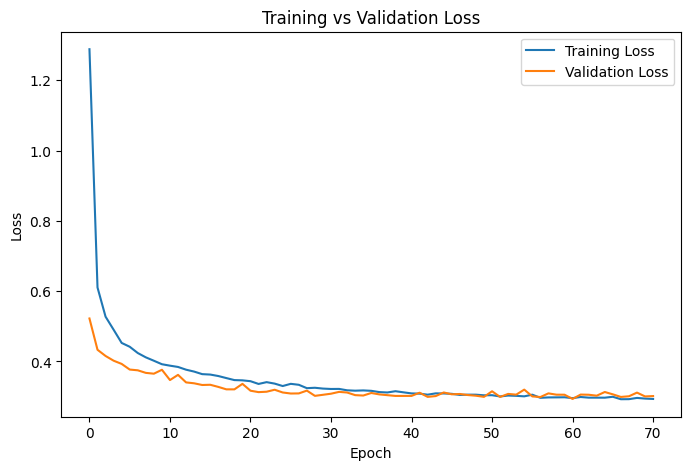

In [12]:
# =====================================
# STEP 12: Loss Curve Visualization
# =====================================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [13]:
# =====================================
# STEP 13: Overfitting Check
# =====================================
print("\nFinal Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])


Final Training Loss: 0.29329532384872437
Final Validation Loss: 0.301488995552063


In [14]:
# =====================================
# STEP 14: Compare with ML Model (Optional)
# =====================================
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest R2:", r2_score(y_test, y_pred_rf))


Random Forest R2: 0.8192786104442945


In [15]:
# =====================================
# STEP 15: Save Model
# =====================================
model.save("house_price_dnn_model.keras")

print("\nModel Saved Successfully!")


Model Saved Successfully!
